# Deep-dive into trained models

Recall the high-level structure of NeuralGCM models, from Figure 1 of the
[NeuralGCM paper](https://www.nature.com/articles/s41586-024-07744-y):

![](https://raw.githubusercontent.com/neuralgcm/neuralgcm/main/docs/_static/neuralgcm-flowchart.png)

In **neuralgcm-torch** this structure is a plain `torch.nn.Module`
tree: a `StochasticModularStepModel` composed of an encoder, a decoder, an
advance step (dycore corrector + neural physics + stochastic fields) and a
forcing module. This notebook pokes at those pieces. It runs entirely from
files packaged with the repository (no network needed).

## Loading a model

Pre-trained models are loaded from *converted* checkpoints with
`PressureLevelModel.from_checkpoint`, as shown in the forecast_quickstart
notebook. Here we use the very small (toy) TL63 stochastic model packaged
with the repository, converting it on first use:

In [2]:
import dataclasses

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray

from dinosaur_torch import horizontal_interpolation
from dinosaur_torch import spherical_harmonic
from dinosaur_torch import xarray_utils
import neuralgcm_torch as neuralgcm

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
from neuralgcm_torch import pretrained
# Fetched from the Hugging Face Hub on first use (cached), or reused from
# a local checkpoints/ directory if present.
converted_path = pretrained.fetch_checkpoint('tl63_stochastic_mini', local_root='checkpoints')
model = neuralgcm.PressureLevelModel.from_checkpoint(converted_path, device=device)

The data_preparation notebook describes how to prepare data in detail.
Here we'll regrid the single ERA5 snapshot packaged with the repository to
the required resolution:

In [4]:
import importlib.resources

with importlib.resources.files('neuralgcm_torch').joinpath(
    'data/era5_tl31_19590102T00.nc'
).open('rb') as f:
  ds = xarray.load_dataset(f).expand_dims('time')

regridder = horizontal_interpolation.ConservativeRegridder(
    spherical_harmonic.GridSpec.TL31(), model.data_grid, device=device
)
ds = xarray_utils.regrid_horizontal(ds, regridder)
inputs, forcings = model.data_from_xarray(ds)

./dinosaur-torch/dinosaur_torch/xarray_utils.py:235: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  field = torch.as_tensor(


## Encoding & decoding data

`encode` transforms input data (on pressure levels) into model variables
(on sigma levels). To use it, pass in dictionaries of input and forcing
data and, for stochastic models, an integer seed:

In [5]:
encoded = model.encode(inputs, forcings, rng=0)

`decode` can be used to convert back from model levels to pressure levels:

In [6]:
decoded = model.decode(encoded, forcings)

Encoding/decoding is a lossy process, because NeuralGCM's encoded model
state uses a different coordinate system. For this model, it introduces
about 1 degree of error on average near the surface:

In [7]:
float(abs(inputs['temperature'][0, -1] - decoded['temperature'][-1]).mean())

1.2497444152832031

## Inside the model

The wrapped model is an ordinary `nn.Module`; its parameters are real
registered parameters (no parameter trees on the side):

In [8]:
for name, child in model.model.named_children():
  n_params = sum(p.numel() for p in child.parameters())
  print(f'{name:16s} {type(child).__name__:55s} {n_params:>10,} params')
print(f'{"total":74s} {sum(p.numel() for p in model.model.parameters()):>10,} params')

encoder          DimensionalLearnedWeatherbenchToPrimitiveEncoder            56,628 params
decoder          DimensionalLearnedPrimitiveToWeatherbenchDecoder            58,016 params
advance_module   StochasticPhysicsParameterizationStep                       76,530 params
forcing_module   DynamicDataForcing                                               0 params
total                                                                         191,174 params


Standard PyTorch tooling applies: `state_dict()` for saving/loading,
`named_parameters()` for optimizer param groups, hooks, etc. The advance
step is itself composed of a dycore corrector, the neural physics
parameterization and the stochastic field module:

In [9]:
for name, child in model.model.advance_module.named_children():
  print(f'{name:28s} {type(child).__name__}')

corrector                    CustomCoordsCorrector
physics_parameterization     DivCurlNeuralParameterization
randomness_module            BatchGaussianRandomFieldModule


## Advancing in time

`advance` and `unroll` step the encoded model state forward in time, using
a combination of the NeuralGCM dycore and learned physics. `advance` takes
a single time-step of size `model.timestep`:

In [10]:
assert model.timestep == np.timedelta64(3600, 's')
advanced = model.advance(encoded, forcings)

`unroll` is the higher-level method for stepping forward multiple steps at
once, decoding outputs at a given time interval:

In [11]:
advanced, outputs = model.unroll(
    encoded, forcings, steps=4, timedelta=np.timedelta64(1, 'h')
)
{k: tuple(v.shape) for k, v in outputs.items()}

{'u_component_of_wind': (4, 37, 128, 64),
 'v_component_of_wind': (4, 37, 128, 64),
 'temperature': (4, 37, 128, 64),
 'geopotential': (4, 37, 128, 64),
 'sim_time': (4,),
 'specific_humidity': (4, 37, 128, 64),
 'specific_cloud_ice_water_content': (4, 37, 128, 64),
 'specific_cloud_liquid_water_content': (4, 37, 128, 64)}

At each model time-step, the forcing nearest in time is used, which allows
for supplying forcings at coarser time resolution than the model timestep
(here a single snapshot, i.e. persistence). The `advanced` state is the
updated encoded state after taking all of the indicated time-steps, which
could be fed back into `unroll` to advance further in time.

For long rollouts, see `model.compile(...)` (optionally with
`cudagraphs=True`) in the README — it makes each step several times
faster after a one-time compilation cost.

## Autograd and fine-tuning

The entire model — encoder, neural physics, dynamical core, decoder — is
differentiable end to end with plain autograd. As a demonstration, we
compute a rollout loss against a persistence target and look at the
gradient magnitudes reaching each component:

In [12]:
from neuralgcm_torch import training

dt = float(model.to_nondim_units(
    model.timestep / np.timedelta64(1, 's'), 's'
))
targets = {k: v.clone() for k, v in inputs.items()}
targets['sim_time'] = inputs['sim_time'] + dt  # persistence, one step later

loss = training.rollout_loss(model, inputs, forcings, targets, rng=0)
loss.backward()
for name, child in model.model.named_children():
  norms = [p.grad.norm() for p in child.parameters() if p.grad is not None]
  total = float(torch.stack(norms).norm()) if norms else 0.0
  print(f'{name:16s} grad norm {total:.3e}')
model.model.zero_grad(set_to_none=True)

encoder          grad norm 3.378e+04
decoder          grad norm 4.054e+04
advance_module   grad norm 3.666e+03
forcing_module   grad norm 0.000e+00


For an actual training loop, `data.TrajectoryDataset` windows an
ERA5-style dataset into (inputs, forcings, targets) examples and
`training.train_step` performs `torch.optim` updates — see the README.
Memory scales with the number of advance steps kept on the autodiff tape,
so rollout-training uses short rollouts (1-3 output frames).

## Encoded model state

**Warning:** there are no stable API guarantees for encoded model state.
Expect different models (especially future versions of NeuralGCM) to store
different collections of data in different formats.

Model state is a nested dataclass registered as a torch pytree; mapping
shapes over it gives a compact view of its structure:

In [13]:
torch.utils._pytree.tree_map(
    lambda x: tuple(x.shape) if hasattr(x, 'shape') else x, encoded
)

ModelState(state=State(vorticity=(32, 128, 65), divergence=(32, 128, 65), temperature_variation=(32, 128, 65), log_surface_pressure=(1, 128, 65), tracers={'specific_humidity': (32, 128, 65), 'specific_cloud_ice_water_content': (32, 128, 65), 'specific_cloud_liquid_water_content': (32, 128, 65)}, sim_time=()), memory=None, diagnostics={}, randomness=RandomnessState(core=(10, 128, 65), nodal_value=(10, 128, 64), modal_value=(10, 128, 65), prng_key=6220207618836018757, prng_step=0))

Internally, model state is represented using a different set of variables
(vorticity, divergence, temperature variation and log surface pressure)
more appropriate to NeuralGCM's spectral dynamical core. Each variable is
stored in the spherical harmonic basis on sigma levels; converting to
velocities on the nodal (lat/lon) grid:

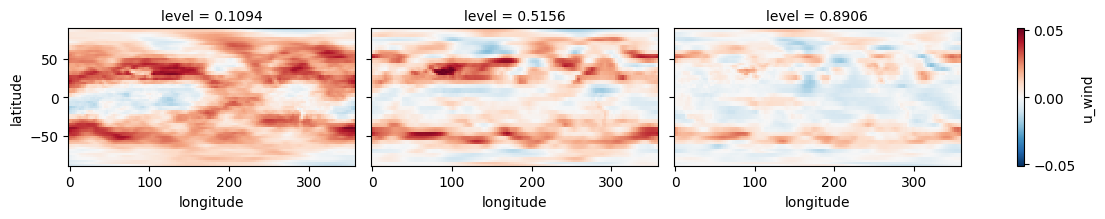

In [14]:
coords = model.model.decoder.coords
nodal_u, nodal_v = coords.horizontal.vor_div_to_uv_nodal(
    encoded.state.vorticity, encoded.state.divergence
)
encoded_ds = xarray.Dataset(
    {
        'u_wind': (('level', 'longitude', 'latitude'), nodal_u.cpu().numpy()),
        'v_wind': (('level', 'longitude', 'latitude'), nodal_v.cpu().numpy()),
    },
    coords={
        'level': coords.vertical.coordinates.centers,  # sigma (NumPy)
        'longitude': model.longitudes,
        'latitude': model.latitudes,
    },
)
encoded_ds.u_wind.sel(level=[0.1, 0.5, 0.9], method='nearest').plot.imshow(
    x='longitude', y='latitude', col='level', aspect=1.6, size=2.3
);

You can also work with state in the spherical harmonic (modal)
representation, which is sometimes convenient, e.g., for calculating power
spectra. Here care should be taken to ensure that structural sparsity is
handled properly:

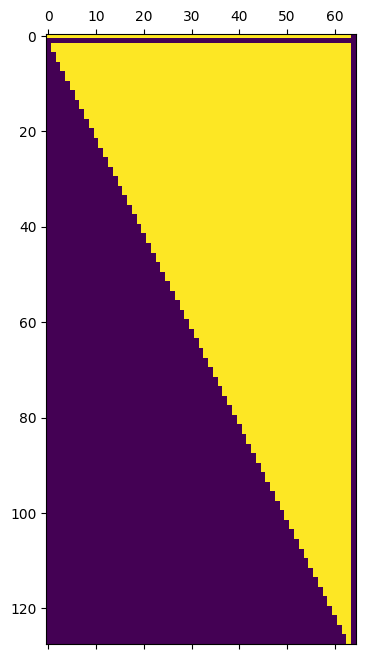

In [15]:
plt.matshow((encoded.state.temperature_variation[0] != 0).cpu());

The non-zero mask can be accessed programmatically:

In [16]:
coords.horizontal.mask

array([[ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       [False,  True,  True, ...,  True,  True,  True],
       ...,
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ..., False,  True,  True],
       [False, False, False, ..., False,  True,  True]], shape=(128, 65))

## Random noise

NeuralGCM stochastic models use deterministic and explicit random number
generation. In -next, randomness is seeded by plain integers (internally
expanded with splitmix64 into per-draw `torch.Generator`s); random streams
are deterministic given the seed, and statistically — not bitwise —
equivalent to the original JAX models. Different seeds give different
encodings:

In [17]:
encoded = model.encode(inputs, forcings, rng=0)
encoded2 = model.encode(inputs, forcings, rng=1)
# slightly different average temperatures
(float(encoded.state.temperature_variation.mean()),
 float(encoded2.state.temperature_variation.mean()))

(-0.003968254663050175, -0.003972785547375679)

Randomness in the learned physics is controlled via the same `rng`
argument, which seeds the Gaussian random fields carried on the model
state. You can visualize them:

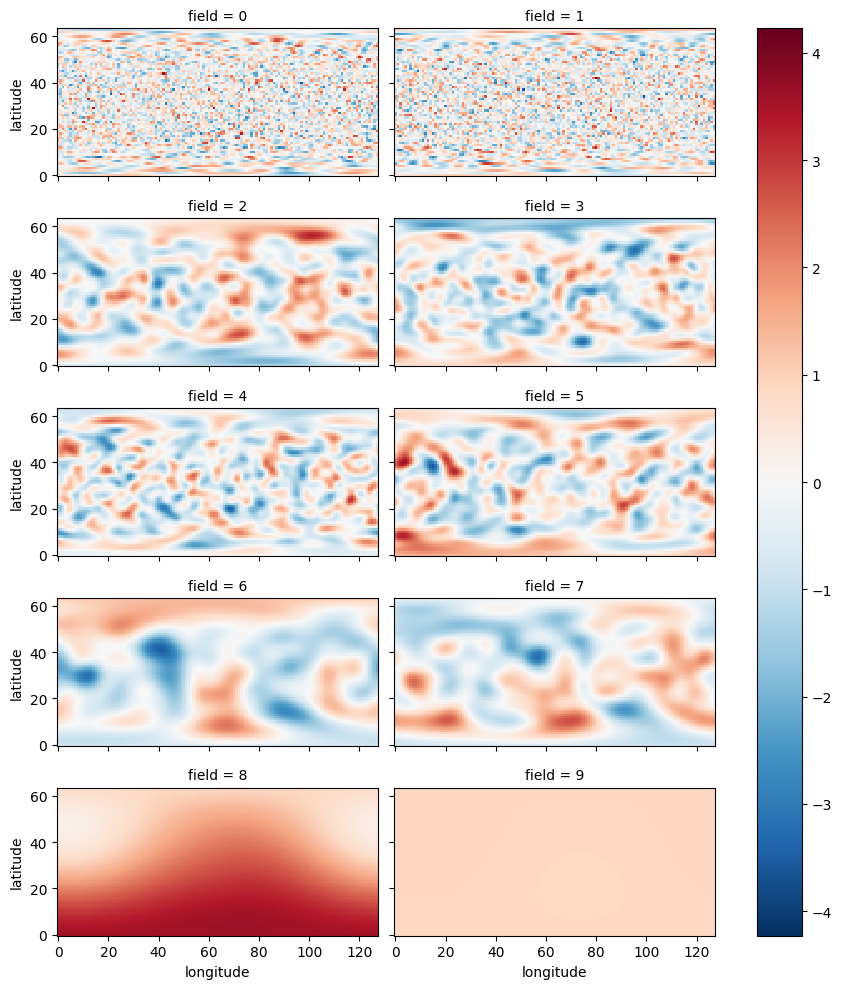

In [18]:
xarray.DataArray(
    encoded.randomness.nodal_value.cpu().numpy(),
    dims=['field', 'longitude', 'latitude'],
).plot(x='longitude', y='latitude', col='field', col_wrap=2, aspect=2, size=2);

Adjusting random noise on an existing model state is also possible by
replacing `randomness.prng_key` (an integer in -next); the states will
slowly diverge after advancing in time due to new noise being injected at
each time step:

In [19]:
encoded_with_new_rng = dataclasses.replace(
    encoded,
    randomness=dataclasses.replace(encoded.randomness, prng_key=123),
)
advanced = model.advance(encoded, forcings)
advanced_with_new_rng = model.advance(encoded_with_new_rng, forcings)
(float(advanced.state.temperature_variation.mean()),
 float(advanced_with_new_rng.state.temperature_variation.mean()))

(-0.004131820518523455, -0.004131820518523455)